## 环境与路径设置

本节只设置路径、输出目录和常用依赖。核心 CME、监督构建、训练和建树函数都从 `src/` 导入。

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import torch
from scipy import sparse

REPO_ROOT = Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
OUTPUT_DIR = REPO_ROOT / "outputs" / "notebook_demo"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

导入项目内已有函数。Notebook 只负责编排流程，不在这里重写核心算法。

In [2]:
from src.cme_supervision import (
    build_supervision_from_cme, compute_cme_matrix,
    compute_cme_pvalues, load_expression_from_h5ad,
    save_supervision_npz,
)
from src.cme_visualization import plot_cme_supervision_heatmaps
from src.metagene_tree import (
    build_metagene_tree_from_result, plot_metagene_tree,
    score_cell_types_from_metagene_tree,
    validate_metagene_tree_result,
)
from src.supervision_pipeline import (
    plot_supervision_masks, run_supervised_hyperedges,
    summarize_unassigned_genes,
)

## 读取 ngn3 数据

默认读取 `datasets/adata_ngn3_ss.h5ad`。如果你的文件名或位置不同，只需要替换下面的 `ADATA_PATH`。

In [3]:
ADATA_PATH = REPO_ROOT / "datasets" / "adata_ngn3_ss.h5ad"

if not ADATA_PATH.exists():
    raise FileNotFoundError(
        "请把 ADATA_PATH 替换成你的 ngn3/npn3 .h5ad 文件路径"
    )

adata = sc.read_h5ad(str(ADATA_PATH))
num_cells = int(adata.n_obs)
num_genes = int(adata.n_vars)
RESULT_PREFIX = ADATA_PATH.stem

print({"path": str(ADATA_PATH), "shape": adata.shape})

{'path': 'c:\\Users\\Ideal\\OneDrive\\桌面\\生信教材\\GAMULE-master\\GAMULE-master\\datasets\\adata_ngn3_ss.h5ad', 'shape': (642, 21)}


查看数据结构，确认细胞标签、基因名和是否已有 UMAP。ngn3 这份示例数据只有一个 `clusters` 类别，因此不能验证多细胞类型准确率。

In [4]:
metadata_summary = {
    "obs_columns": list(map(str, adata.obs.columns)),
    "var_columns": list(map(str, adata.var.columns)),
    "layers": list(map(str, adata.layers.keys())),
    "obsm": list(map(str, adata.obsm.keys())),
    "genes": list(map(str, adata.var_names)),
}
display(metadata_summary)

if "clusters" in adata.obs:
    display(adata.obs["clusters"].astype(str).value_counts())

{'obs_columns': ['clusters_coarse', 'clusters', 'S_score', 'G2M_score'],
 'var_columns': ['highly_variable_genes'],
 'layers': ['spliced', 'unspliced'],
 'obsm': ['X_pca', 'X_umap'],
 'genes': ['Pax6',
  'Cpe',
  'Gars',
  'Hpca',
  'Celf3',
  'Rgs17',
  'Tuba1a',
  'Ndc80',
  'Racgap1',
  'Aurkb',
  'Cdk1',
  'Prc1',
  'Cdc20',
  'Ccnb1',
  'Dbi',
  'Mgst1',
  'Sparc',
  'Spp1',
  'Id1',
  'Vim',
  'Acot1']}

clusters
Ngn3 high EP    642
Name: count, dtype: int64

## 运行主分析流程

这里使用三种 gene-pair 监督：互斥负监督、Jaccard 正监督、包含弱正监督，并额外加入很弱的有向包含正则。

In [5]:
seed = 0
t_CME = 0.66
t_p = 0.05
t_Jaccard = 0.50
k_Jaccard = 297
t_inclusion = 0.10
hierarchy_strength = 0.001
n_permutations = 100
num_gene_modules = 3
num_hyperedges = num_gene_modules + 1

torch.manual_seed(seed)
run_config = dict(locals())
display({k: run_config[k] for k in [
    "seed", "t_CME", "t_Jaccard", "t_inclusion",
    "hierarchy_strength", "num_gene_modules"]})

{'seed': 0,
 't_CME': 0.66,
 't_Jaccard': 0.5,
 't_inclusion': 0.1,
 'hierarchy_strength': 0.001,
 'num_gene_modules': 3}

计算 gene-by-cell 表达矩阵、CME 矩阵和置换 p-value。

In [6]:
expression = load_expression_from_h5ad(ADATA_PATH, num_genes=num_genes)
cme_matrix = compute_cme_matrix(
    expression.matrix, normalize=False, use_numba=True
)
pval_matrix = compute_cme_pvalues(
    expression.matrix, cme_matrix,
    n_permutations=n_permutations, seed=seed,
    use_numba=True,
)
print(cme_matrix.shape, pval_matrix.shape)

C:\Users\Ideal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numba\core\decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


(21, 21) (21, 21)


从 CME 构建三路监督 mask，并保存监督矩阵。

In [7]:
supervision = build_supervision_from_cme(
    cme_matrix, pval_matrix,
    cme_threshold=t_CME, pvalue_threshold=t_p,
    jaccard_threshold=t_Jaccard, top_k=k_Jaccard,
    inclusion_threshold=t_inclusion,
)
pos_mask = torch.from_numpy(supervision.positive_mask)
neg_mask = torch.from_numpy(supervision.negative_mask)
partial_pos_mask = torch.from_numpy(supervision.inclusion_partial_mask)
directed_inclusion_mask = torch.from_numpy(supervision.inclusion_directed_mask)

save_supervision_npz(
    OUTPUT_DIR / f"{RESULT_PREFIX}_supervision.npz",
    cme_matrix=cme_matrix, pval_matrix=pval_matrix,
    supervision=supervision,
)

训练 gene-hyperedge assignment。这里的有向包含信息作为很弱的 module-level 正则项加入。

In [8]:
result = run_supervised_hyperedges(
    adata=adata, pos_mask=pos_mask, neg_mask=neg_mask,
    partial_pos_mask=partial_pos_mask,
    directed_inclusion_mask=directed_inclusion_mask,
    num_genes=num_genes, num_hyperedges=num_hyperedges,
    use_unassigned_hyperedge=True,
    pos_strength=0.5, partial_pos_strength=0.25,
    neg_strength=0.0, hierarchy_strength=hierarchy_strength,
    epochs=10000, lr=0.016, entropy_strength=0.001,
    ranges_map=None, device="auto", seed=seed,
)

Epoch 1/10000, Loss: 0.133677557, full_pos(>= 0.5): 0.025192784, partial_pos(>= 0.25): 0.000000000, neg(->0): 0.107419051, hierarchy_directed: 0.000608279, Entropy: 1.0651
Epoch 100/10000, Loss: 0.003908570, full_pos(>= 0.5): 0.000060146, partial_pos(>= 0.25): 0.000077038, neg(->0): 0.002907654, hierarchy_directed: 0.011954500, Entropy: 0.8518
Epoch 200/10000, Loss: 0.003251475, full_pos(>= 0.5): 0.000078343, partial_pos(>= 0.25): 0.000032217, neg(->0): 0.002291444, hierarchy_directed: 0.012542584, Entropy: 0.8369
Epoch 300/10000, Loss: 0.001972933, full_pos(>= 0.5): 0.000068927, partial_pos(>= 0.25): 0.000083685, neg(->0): 0.001023984, hierarchy_directed: 0.015898149, Entropy: 0.7804
Epoch 400/10000, Loss: 0.001430105, full_pos(>= 0.5): 0.000009469, partial_pos(>= 0.25): 0.000203343, neg(->0): 0.000457380, hierarchy_directed: 0.017810177, Entropy: 0.7421
Epoch 500/10000, Loss: 0.001288686, full_pos(>= 0.5): 0.000003320, partial_pos(>= 0.25): 0.000184675, neg(->0): 0.000355605, hierarc

基于训练得到的 hyperedges 构建 metagene tree。真实 ngn3 数据没有 `gene_module` 真值列时，按无监督结果输出。

In [9]:
reference_adata = adata if "gene_module" in adata.var.columns else None
metagene_tree = build_metagene_tree_from_result(
    result, expression.matrix, adata=reference_adata,
    gene_names=expression.gene_names,
    reference_column="gene_module",
    cme_threshold=t_CME, assignment="argmax",
    aggregation="sum", child_strategy="max_degree_ties",
)
tree_validation = validate_metagene_tree_result(metagene_tree)
display(tree_validation)

{'num_nodes': 4,
 'tree_edges': 3,
 'tree_has_all_nodes': True,
 'tree_edge_count_ok': True,
 'root_is_empty_node': True,
 'mutex_graph_is_symmetric': True,
 'complement_graph_is_symmetric': True}

## 展示 QC 指标

这些指标用于检查监督信号是否足够、mask 是否冲突、训练是否留下大量未分配基因。

In [10]:
mask_summary = {
    "full_pos": int(pos_mask.sum().item()),
    "partial_pos": int(partial_pos_mask.sum().item()),
    "directed_inclusion": int(directed_inclusion_mask.sum().item()),
    "neg": int(neg_mask.sum().item()),
}
display(supervision.stats)
display(mask_summary)
display(summarize_unassigned_genes(result))

{'num_genes': 21,
 'cme_threshold': 0.66,
 'pvalue_threshold': 0.05,
 'jaccard_threshold': 0.5,
 'top_k': 297,
 'inclusion_threshold': 0.1,
 'negative_pairs': 56,
 'positive_pairs': 13,
 'inclusion_directed_pairs': 97,
 'inclusion_partial_pairs': 95,
 'positive_negative_overlap': 0,
 'inclusion_positive_overlap_moved_to_partial': 33,
 'inclusion_negative_overlap_removed': 2,
 'genes_with_negative_signal': 21,
 'genes_with_positive_signal': 12,
 'genes_with_inclusion_signal': 21}

{'full_pos': 26, 'partial_pos': 190, 'directed_inclusion': 97, 'neg': 112}

{'num_gene_modules': 3,
 'num_hyperedges_total': 4,
 'null_hyperedge_index': 3,
 'supervised_genes': 21,
 'unassigned_genes': 0}

导出 gene module 表和树边表，方便和外部 marker/热图结果对照。

In [11]:
module_rows = []
for node_idx, module_idx in enumerate(metagene_tree.module_ids):
    genes = metagene_tree.module_gene_names.get(module_idx, [])
    module_rows.append({
        "node_index": node_idx, "hyperedge": module_idx,
        "num_genes": len(genes), "genes": ";".join(genes),
    })
module_df = pd.DataFrame(module_rows)
module_df.to_csv(OUTPUT_DIR / "gene_modules.csv", index=False)
display(module_df)

,node_index,hyperedge,num_genes,genes
0,0,0,12,Pax6;Cpe;Gars;Hpca;Celf3;Rgs17;Tuba1a;Ndc80;Ra...
1,1,1,1,Cdk1
2,2,2,8,Cdc20;Dbi;Mgst1;Sparc;Spp1;Id1;Vim;Acot1


保存 metagene tree 的边表，后续可以和 marker gene 解释一起检查层级关系。

In [12]:
labels = metagene_tree.node_labels
edge_rows = [
    {"parent": labels[p], "child": labels[c],
     "parent_idx": int(p), "child_idx": int(c)}
    for p, c in metagene_tree.tree_edges
]
edge_df = pd.DataFrame(edge_rows)
edge_df.to_csv(OUTPUT_DIR / "tree_edges.csv", index=False)
display(edge_df)

,parent,child,parent_idx,child_idx
0,EMPTY\nn=0,H0\nn=12,3,0
1,EMPTY\nn=0,H1\nn=1,3,1
2,EMPTY\nn=0,H2\nn=8,3,2


## 可视化主要结果

先画 UMAP。如果数据里没有 `X_umap`，则明确提示并跳过。

In [ ]:
if "X_umap" in adata.obsm:
    color = "clusters" if "clusters" in adata.obs else None
    sc.pl.umap(adata, color=color, show=False)
    plt.savefig(OUTPUT_DIR / "umap.png", dpi=180, bbox_inches="tight")
    plt.show()
else:
    print("There is no UMAP embedding. Skipping UMAP plot.")

复用原 `run.py` 的表达热图思路：直接画 cell × gene 的表达矩阵。

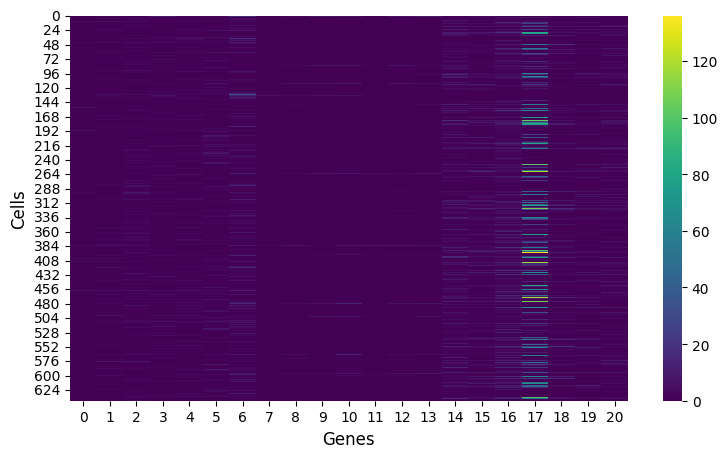

In [ ]:
x_dense = adata.X.toarray() if sparse.issparse(adata.X) else adata.X
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(x_dense, ax=ax, cmap="viridis")
ax.set_xlabel("Genes", fontsize=12)
ax.set_ylabel("Cells", fontsize=12)
fig.savefig(OUTPUT_DIR / "expression_heatmap.png", dpi=180,
            bbox_inches="tight")
plt.show()

按你提供的 marker gene 顺序画 gene-gene 表达相关性热图，用来和真实热图三块结构对照。

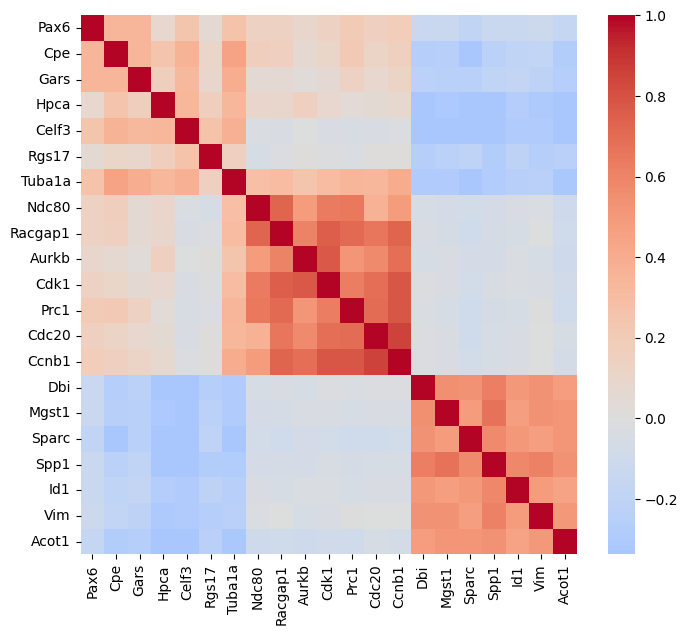

In [ ]:
marker_groups = [
    ["Pax6", "Cpe", "Gars", "Hpca", "Celf3", "Rgs17", "Tuba1a"],
    ["Ndc80", "Racgap1", "Aurkb", "Cdk1", "Prc1", "Cdc20", "Ccnb1"],
    ["Dbi", "Mgst1", "Sparc", "Spp1", "Id1", "Vim", "Acot1"],
]
marker_genes = [g for group in marker_groups for g in group]
marker_genes = [g for g in marker_genes if g in adata.var_names]
marker_x = adata[:, marker_genes].X
marker_x = marker_x.toarray() if sparse.issparse(marker_x) else marker_x
corr = np.corrcoef(marker_x.T)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr, xticklabels=marker_genes, yticklabels=marker_genes,
            cmap="coolwarm", center=0, robust=True,ax=ax)
fig.savefig(OUTPUT_DIR / "marker_gene_correlation_heatmap.png",
            dpi=180, bbox_inches="tight")

展示 CME、p-value、正负监督和包含监督的热图。

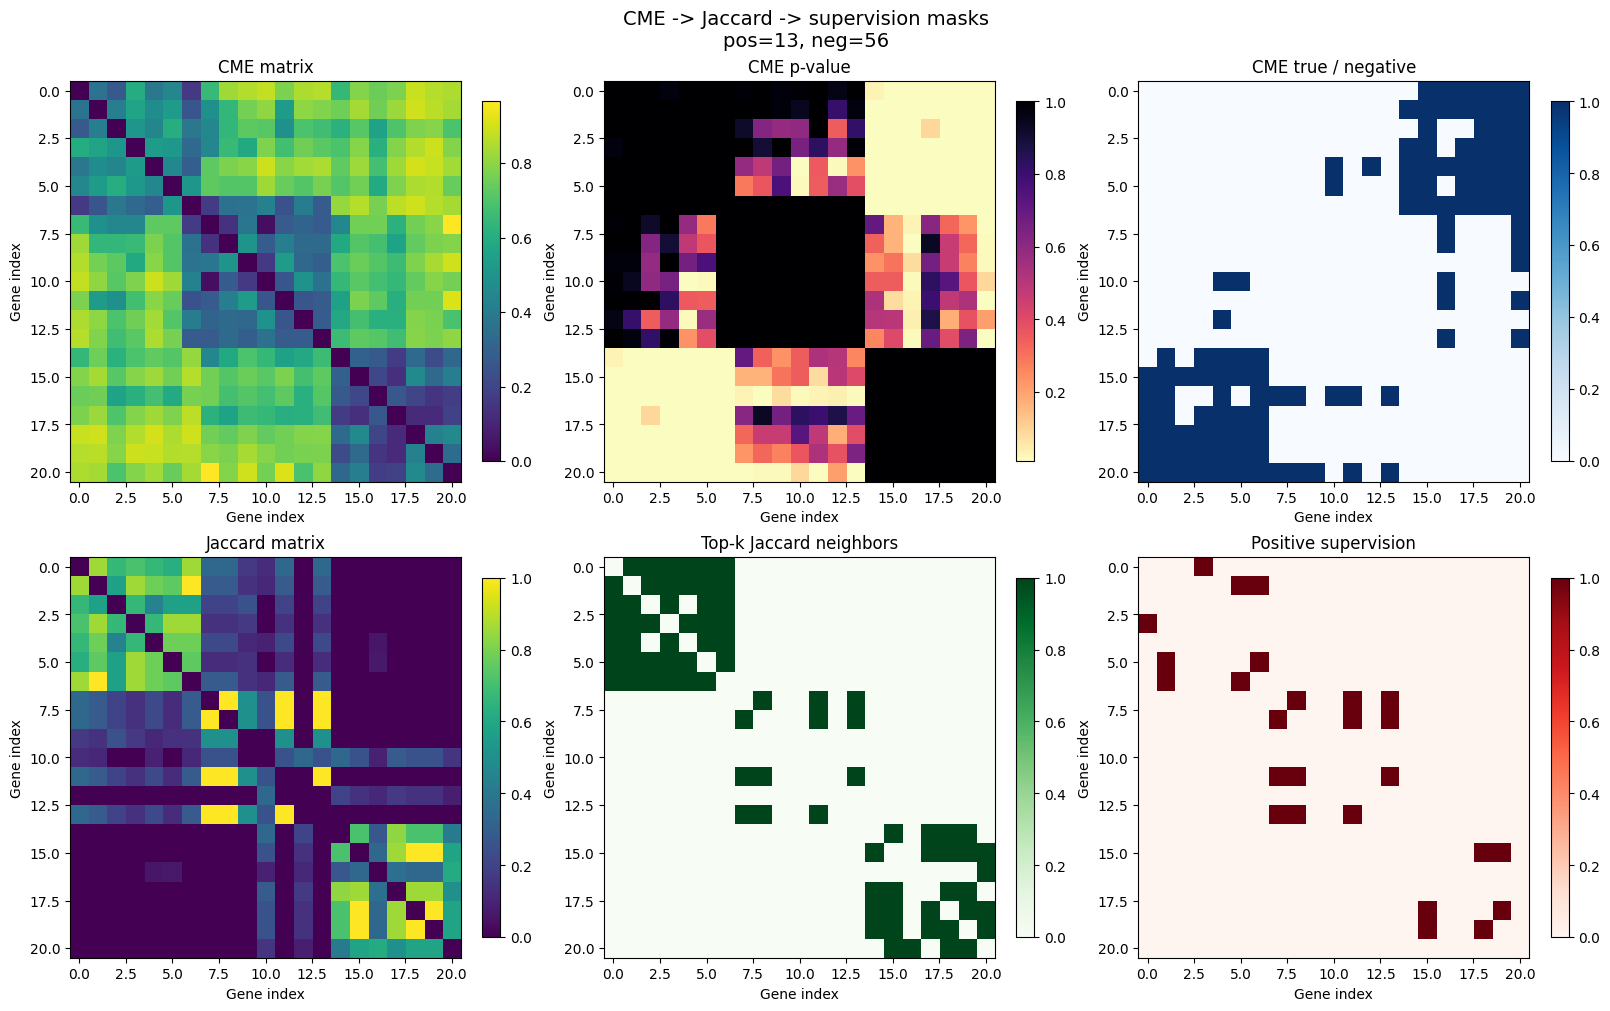

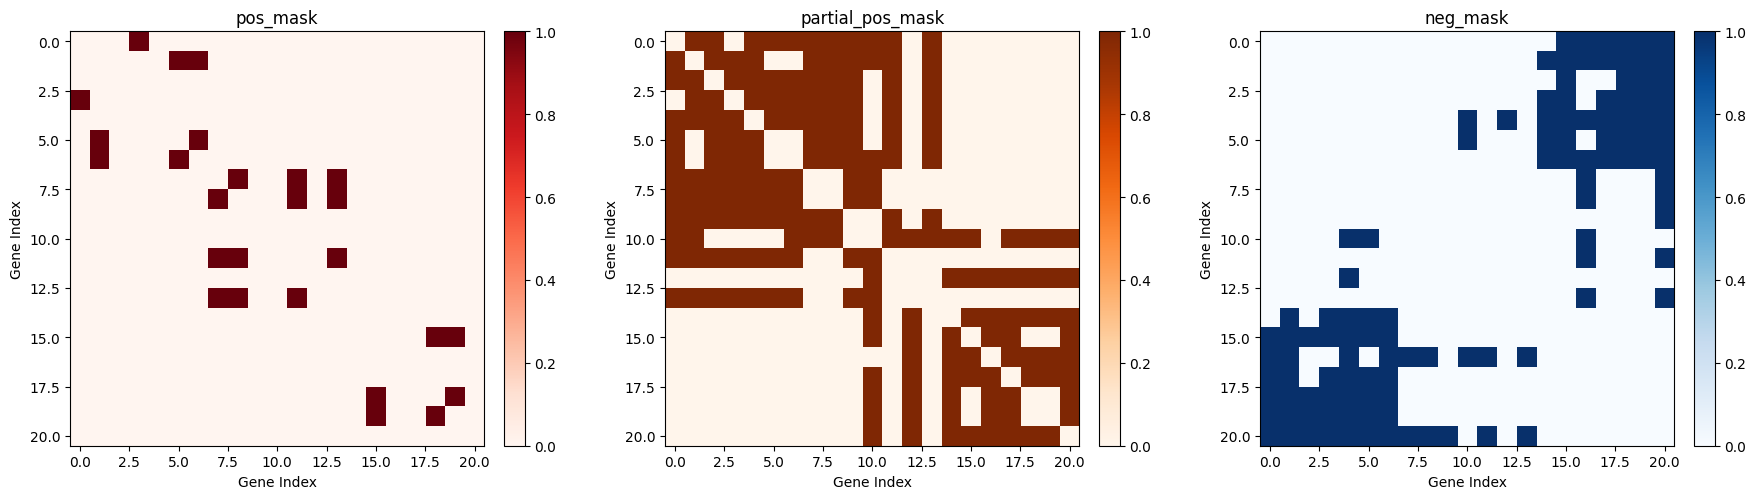

In [ ]:
plot_cme_supervision_heatmaps(
    cme_matrix=cme_matrix, pval_matrix=pval_matrix,
    supervision=supervision,
    save_path=OUTPUT_DIR / "cme_supervision_heatmaps.png",
    show=True,
)
fig = plot_supervision_masks(
    pos_mask, neg_mask, partial_pos_mask=partial_pos_mask,
)
fig.savefig(OUTPUT_DIR / "supervision_masks.png", dpi=180,
            bbox_inches="tight")

画 metagene tree，并保存 PNG。

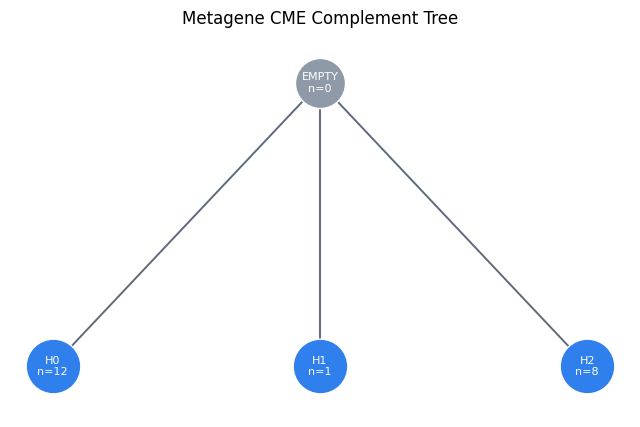

In [ ]:
fig = plot_metagene_tree(
    metagene_tree,
    save_path=OUTPUT_DIR / "metagene_cme_tree.png",
)
plt.show()

pd.DataFrame(
    metagene_tree.metagene_cme,
    index=metagene_tree.node_labels[:-1],
    columns=metagene_tree.node_labels[:-1],
).to_csv(OUTPUT_DIR / "metagene_cme.csv")

## 尝试 2-3 组关键参数

这里做一个很小的参数对照。它不是完整网格搜索，只用于快速观察 `t_CME`、`t_Jaccard` 和有向包含正则对模块分组的影响。

In [ ]:
quick_configs = [
    {"name": "best_heatmap_like", "t_CME": 0.66,
     "t_Jaccard": 0.50, "t_inclusion": 0.10, "h": 0.0},
    {"name": "with_directed", "t_CME": 0.66,
     "t_Jaccard": 0.50, "t_inclusion": 0.10, "h": 0.001},
    {"name": "stricter_cme", "t_CME": 0.75,
     "t_Jaccard": 0.65, "t_inclusion": 0.15, "h": 0.001},
]
display(pd.DataFrame(quick_configs))

,name,t_CME,t_Jaccard,t_inclusion,h
0,best_heatmap_like,0.66,0.50,0.10,0.000
1,with_directed,0.66,0.50,0.10,0.001
2,stricter_cme,0.75,0.65,0.15,0.001


定义一个轻量函数：每次只调用 `src` 里的监督构建和训练函数，然后返回模块基因列表。

In [ ]:
def fit_quick_config(cfg, epochs=800):
    sup = build_supervision_from_cme(
        cme_matrix, pval_matrix, cme_threshold=cfg["t_CME"],
        pvalue_threshold=t_p, jaccard_threshold=cfg["t_Jaccard"],
        top_k=k_Jaccard, inclusion_threshold=cfg["t_inclusion"])
    res = run_supervised_hyperedges(
        adata=adata, pos_mask=torch.from_numpy(sup.positive_mask),
        neg_mask=torch.from_numpy(sup.negative_mask),
        partial_pos_mask=torch.from_numpy(sup.inclusion_partial_mask),
        directed_inclusion_mask=torch.from_numpy(sup.inclusion_directed_mask),
        num_genes=num_genes, num_hyperedges=4,
        pos_strength=0.5, partial_pos_strength=0.25,
        neg_strength=0.0, hierarchy_strength=cfg["h"],
        epochs=epochs, lr=0.016, entropy_strength=0.001,
        ranges_map=None, device="auto", seed=seed)
    labels = res.partition[:, :3].argmax(dim=1).cpu().tolist()
    return labels

运行 3 组快速参数，并保存模块分配结果。

In [ ]:
trial_rows = []
for cfg in quick_configs:
    labels = fit_quick_config(cfg)
    for module_id in sorted(set(labels)):
        genes = [g for g, z in zip(adata.var_names, labels) if z == module_id]
        trial_rows.append({
            "config": cfg["name"], "module": int(module_id),
            "num_genes": len(genes), "genes": ";".join(map(str, genes)),
        })
trial_df = pd.DataFrame(trial_rows)
trial_df.to_csv(OUTPUT_DIR / "quick_parameter_trials.csv", index=False)
display(trial_df)

Epoch 1/800, Loss: 0.133676946, full_pos(>= 0.5): 0.025192784, partial_pos(>= 0.25): 0.000000000, neg(->0): 0.107419051, Entropy: 1.0651
Epoch 100/800, Loss: 0.003896692, full_pos(>= 0.5): 0.000059654, partial_pos(>= 0.25): 0.000076976, neg(->0): 0.002908433, Entropy: 0.8516
Epoch 200/800, Loss: 0.003227566, full_pos(>= 0.5): 0.000078263, partial_pos(>= 0.25): 0.000031826, neg(->0): 0.002281446, Entropy: 0.8360
Epoch 300/800, Loss: 0.001938457, full_pos(>= 0.5): 0.000068812, partial_pos(>= 0.25): 0.000086860, neg(->0): 0.001003933, Entropy: 0.7789
Epoch 400/800, Loss: 0.001406397, full_pos(>= 0.5): 0.000008604, partial_pos(>= 0.25): 0.000205925, neg(->0): 0.000452916, Entropy: 0.7390
Epoch 500/800, Loss: 0.001269778, full_pos(>= 0.5): 0.000003098, partial_pos(>= 0.25): 0.000185212, neg(->0): 0.000355087, Entropy: 0.7264
Epoch 600/800, Loss: 0.001201393, full_pos(>= 0.5): 0.000000672, partial_pos(>= 0.25): 0.000169983, neg(->0): 0.000312947, Entropy: 0.7178
Epoch 700/800, Loss: 0.001160

,config,module,num_genes,genes
0,best_heatmap_like,0,7,Pax6;Cpe;Gars;Hpca;Celf3;Rgs17;Tuba1a
1,best_heatmap_like,1,6,Ndc80;Racgap1;Aurkb;Cdk1;Prc1;Ccnb1
2,best_heatmap_like,2,8,Cdc20;Dbi;Mgst1;Sparc;Spp1;Id1;Vim;Acot1
3,with_directed,0,7,Pax6;Cpe;Gars;Hpca;Celf3;Rgs17;Tuba1a
4,with_directed,1,6,Ndc80;Racgap1;Aurkb;Cdk1;Prc1;Ccnb1
5,with_directed,2,8,Cdc20;Dbi;Mgst1;Sparc;Spp1;Id1;Vim;Acot1
6,stricter_cme,0,8,Pax6;Cpe;Gars;Hpca;Celf3;Rgs17;Tuba1a;Ndc80
7,stricter_cme,1,4,Racgap1;Aurkb;Prc1;Ccnb1
8,stricter_cme,2,9,Cdk1;Cdc20;Dbi;Mgst1;Sparc;Spp1;Id1;Vim;Acot1


## 保存图和结果

最后保存 summary JSON，记录本次 notebook 使用的主要参数、QC 和输出路径。

In [ ]:
summary = {
    "adata_path": str(ADATA_PATH),
    "shape": list(adata.shape),
    "run_config": {k: run_config[k] for k in [
        "seed", "t_CME", "t_Jaccard", "t_inclusion",
        "hierarchy_strength", "num_gene_modules"]},
    "supervision_stats": supervision.stats,
    "mask_summary": mask_summary,
    "tree_validation": tree_validation,
    "outputs_dir": str(OUTPUT_DIR),
}
with open(OUTPUT_DIR / "summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2, default=str)

display(summary)

{'adata_path': 'c:\\Users\\Ideal\\OneDrive\\桌面\\生信教材\\GAMULE-master\\GAMULE-master\\datasets\\adata_ngn3_ss.h5ad',
 'shape': [642, 21],
 'run_config': {'seed': 0,
  't_CME': 0.66,
  't_Jaccard': 0.5,
  't_inclusion': 0.1,
  'hierarchy_strength': 0.001,
  'num_gene_modules': 3},
 'supervision_stats': {'num_genes': 21,
  'cme_threshold': 0.66,
  'pvalue_threshold': 0.05,
  'jaccard_threshold': 0.5,
  'top_k': 297,
  'inclusion_threshold': 0.1,
  'negative_pairs': 56,
  'positive_pairs': 13,
  'inclusion_directed_pairs': 97,
  'inclusion_partial_pairs': 95,
  'positive_negative_overlap': 0,
  'inclusion_positive_overlap_moved_to_partial': 33,
  'inclusion_negative_overlap_removed': 2,
  'genes_with_negative_signal': 21,
  'genes_with_positive_signal': 12,
  'genes_with_inclusion_signal': 21},
 'mask_summary': {'full_pos': 26,
  'partial_pos': 190,
  'directed_inclusion': 97,
  'neg': 112},
 'tree_validation': {'num_nodes': 4,
  'tree_edges': 3,
  'tree_has_all_nodes': True,
  'tree_edge_c